Copyright (C) 2025  Diarmuid

This program is free software: you can redistribute it and/or modify\
it under the terms of the GNU General Public License as published by\
the Free Software Foundation, either version 3 of the License, or\
(at your option) any later version.

This program is distributed in the hope that it will be useful,\
but WITHOUT ANY WARRANTY; without even the implied warranty of\
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the\
GNU General Public License for more details.

You should have received a copy of the GNU General Public License\
along with this program.  If not, see <https://www.gnu.org/licenses/>.

----------------------------------------------------------------------

Author: Diarmuid O'Neill\
Student Number: C00282898\
Date: 26/11/2025\
Brief Description:\
This project aims to investigate if sleep and lifestyle factors can \
predict the presence of sleep disorders. The full dataset has 374  
entries. See Technical Specification for more information. \
This notebooks uses K-Means clustering to investigate how different age groups sleep. It is expected that older people will have longer sleep durations than younger people.

Standard Imports

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib. pyplot as plt
import matplotlib.patches as mp
plt.style.use("seaborn-v0_8-whitegrid")
import numpy as np

# K-Means Clustering

In [16]:
dataset = pd.read_csv("Sleep_Health_and_Lifestyle_Dataset.csv")

Text(0.5, 1.0, 'K-Means Clustering: Age vs Sleep Duration')

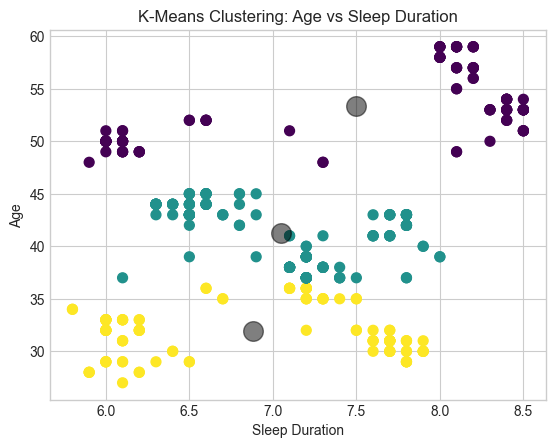

In [4]:
from sklearn.cluster import KMeans

# Get features and column stack to get coordinates
sleepDuration = dataset["Sleep Duration"].values
age = dataset["Age"].values
coords = np.column_stack((sleepDuration, age))

# Fit 3 K-Means clusters
kmeans = KMeans(n_clusters=3)
kmeans.fit(coords)
y_kmeans = kmeans.predict(coords)

# Plot the graph
plt.scatter(coords[:, 0], coords[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
plt.xlabel("Sleep Duration")
plt.ylabel("Age")
plt.title("K-Means Clustering: Age vs Sleep Duration")

After using K-Means to split the data into three distint clusters, we can see that in general older individuals do tend to sleep longer than younger individuals. The green group and the yellow group visible in the graph above have a very similar average sleep durations. However we can see that the purple group, which corresponds with people aged roughly 48 - 60, average sleep duration is higher than the other two groups by just over half an hour.

Next we will try to cluster the data using several more health, sleep and lifestyle features to see if sleeping disorders naturally fall into different clusters. While it is very hard to visualize these clusters effectively, we can instead calculate the percentage occurence of each sleeping disorder in each cluster and see if some clusters contain significantly more of the same sleeping disorders.

In [21]:
# Get features and column stack to get coordinates
age = dataset["Age"].values
sleepDuration = dataset["Sleep Duration"].values
sleepQuality = dataset["Quality of Sleep"].values
physicalActivity = dataset["Physical Activity Level"].values
stressLevel = dataset["Stress Level"].values
heartRate = dataset["Heart Rate"].values
dailySteps = dataset["Daily Steps"].values
coords = np.column_stack((age, sleepDuration, sleepQuality, physicalActivity, stressLevel, heartRate, dailySteps))

# Fit 3 K-Means clusters
kmeans = KMeans(n_clusters=3)
kmeans.fit(coords)
y_kmeans = kmeans.predict(coords)

In [20]:
dataset["Sleep Disorder"] = dataset["Sleep Disorder"].fillna("None")
dataset["Cluster"] = y_kmeans

# Calculate the percentages of each sleeping disorder in each cluster
cluster_disorder_percentage = (
    dataset.groupby("Cluster")["Sleep Disorder"].value_counts(normalize=True).mul(100).rename("Percentage")
)

print(cluster_disorder_percentage)

Cluster  Sleep Disorder
0        None              78.160920
         Sleep Apnea       18.965517
         Insomnia           2.873563
1        None              46.951220
         Insomnia          43.292683
         Sleep Apnea        9.756098
2        Sleep Apnea       80.555556
         None              16.666667
         Insomnia           2.777778
Name: Percentage, dtype: float64


The table above shows us that cluster 0 contains predominantly no sleeping disorders and are likely healthy sleepers with healthier sleep and lifestyle habits. Cluster 1 contains predominantly no sleeping disorders also however, it has a much higher rate of insomnia than the other clusters perhaps indicating this group of people have slightly worse sleeping habits. Cluster 2 overwhelmingly contains sleep apnea cases with very few insomnia cases and no sleeping disorder cases. This may indicate that this cluster contains individuals with much lower health, sleep and lifestyle habits. These patterns show that people naturally group into different risk levels for sleep problems given the feature set.